# Graph embeddings

Environment set up:
* uses mazedyn conda env
* karateclub works but pydot/plotting does not

### Imports

In [110]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from reeb_utils import do_reeb_for_start_end, do_reeb_for_explore_node, plot_treeb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

### Load data

In [111]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")


# test_df[["path_mean_acc_by_Q", "quartile", "StartAt", "EndAt"]]

### Compute treebs

In [112]:
# get all test paths by quartile
# graphs = {}
# for start_node, end_node in test_df.groupby(["StartAt", "EndAt"]).groups.keys():
#     for i in range(1,5):
#         graphs[(start_node, end_node, i)] = do_reeb_for_start_end(test_df, start_node, end_node, i, use_turns=False)

# # extract features for each graph
# features = np.array([extract_tree_features(graphs[g], g[0]+"_0") for g in graphs])
# # get quartiles for each path
# qs = [graph[2] for graph in graphs]



treebs = []
qs = []
accs_by_q = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    for i in range(1,5):
        G = do_reeb_for_start_end(test_df, start_node, end_node, i, use_turns=False)
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
        treebs.append(new_G)
        qs.append(i)
        accs_by_q.append(group[group["quartile"]==i]["path_mean_acc_by_Q"].iloc[0])

### Do graph embeddings

https://karateclub.readthedocs.io/en/latest/modules/root.html#whole-graph-embedding

#### Options:
* **WaveletCharacteristic:** An implementation of “WaveCharacteristic” from the CIKM ‘21 paper “Graph Embedding via Diffusion-Wavelets-Based Node Feature Distribution Characterization”. The procedure uses characteristic functions of node features with wavelet function weights to describe node neighborhoods. These node level features are pooled by mean pooling to create graph level statistics.
* **FeatherGraph:** An implementation of “FEATHER-G” from the CIKM ‘20 paper “Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models”. The procedure uses characteristic functions of node features with random walk weights to describe node neighborhoods. These node level features are pooled by mean pooling to create graph level statistics.
* **Graph2Vec:** An implementation of “Graph2Vec” from the MLGWorkshop ‘17 paper “Graph2Vec: Learning Distributed Representations of Graphs”. The procedure creates Weisfeiler-Lehman tree features for nodes in graphs. Using these features a document (graph) - feature co-occurrence matrix is decomposed in order to generate representations for the graphs.
* **IGE:** An implementation of “Invariant Graph Embedding” from the ICML 2019 Workshop on Learning and Reasoning with Graph-Structured Data paper “Invariant Embedding for Graph Classification”. The procedure computes a mixture of spectral and node embedding based features. Specifically, it uses scattering, eigenvalues and pooled node feature embeddings to create graph descriptors.

In [113]:
## Try to play a bit w the other ones to see if they work
# model = kc.WaveletCharacteristic()
# model = kc.FeatherGraph()
model = kc.Graph2Vec(dimensions=64)
# model = kc.IGE()
model.fit(treebs)

X = model.get_embedding()
print(X.shape)

(288, 64)


In [125]:
features = np.array([extract_tree_features(treeb, 0) for treeb in treebs])
print(features)

[[20.         19.          5.         ...  4.08947368  1.9
   0.        ]
 [22.         21.          6.         ...  4.08658009  1.90909091
   0.        ]
 [12.         11.          5.         ...  2.92424242  1.83333333
   0.        ]
 ...
 [17.         16.          8.         ...  4.36764706  1.88235294
   0.        ]
 [ 6.          5.          3.         ...  1.93333333  1.66666667
   0.        ]
 [ 2.          1.          1.         ...  1.          1.
   0.        ]]


### Cluster graph embeddings

In [130]:
num_clusters = 4

kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(X)

labels = kmeans.labels_

### Evaluate and visualise clustering

ARI: 0.39 (random would be: -0.00)
NMI: 0.46 (random would be: 0.01)
[0.8372396  0.00537744]


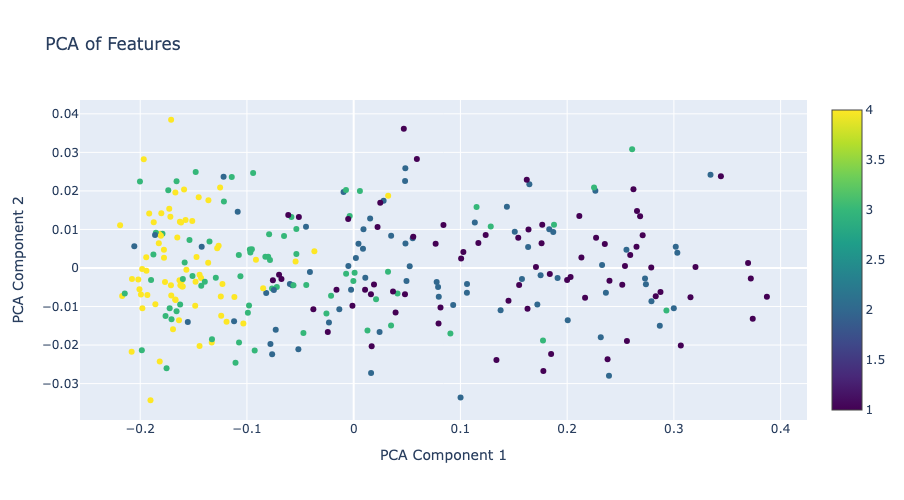

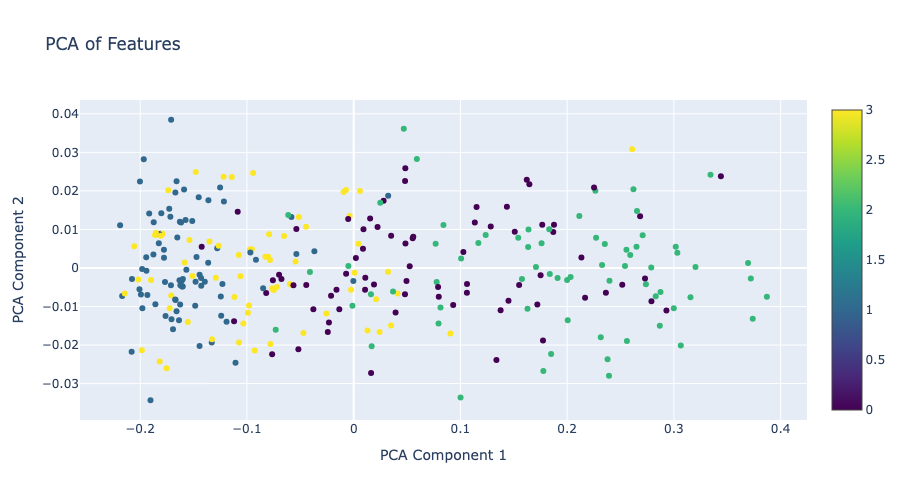

[[1.22774273e-01 2.00313151e-01 2.70701021e-01 1.72224164e-01
  6.35375306e-02 1.97042841e-02 1.10241093e-01 9.33534950e-02
  1.70849606e-01 1.61168177e-03 1.00143319e-02 6.11208798e-03
  2.33476371e-01 8.38460401e-02 1.81591399e-02 1.35089695e-01
  6.77682310e-02 2.39649579e-01 1.67636231e-01 1.66704431e-02
  1.47377849e-01 9.00853351e-02 2.97130533e-02 7.23191574e-02
  1.41039595e-01 8.36277381e-03 1.36977017e-01 1.07957378e-01
  1.60848662e-01 1.12281153e-02 7.62012154e-02 2.82640696e-01
  1.35227755e-01 1.29453778e-01 1.85817145e-02 2.95832921e-02
  8.30934718e-02 4.67320345e-02 8.35777596e-02 2.50501297e-02
  1.08222574e-01 1.53107986e-01 1.92031354e-01 1.14014082e-01
  8.36775601e-02 1.20871529e-01 5.42323291e-02 1.11265182e-02
  2.73272599e-04 1.59290228e-02 7.49243125e-02 2.33751331e-02
  9.64812636e-02 1.58714578e-01 3.25038023e-02 2.95766145e-02
  3.10849816e-01 5.70382476e-02 6.12275004e-02 7.14583248e-02
  3.25984694e-02 5.38034104e-02 2.86098510e-01 1.36499316e-01]
 [1.178

In [132]:
true_labels = [q-1 for q in qs]
baseline = [random.randint(0, 4) for _ in range(len(true_labels))]

print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")



# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(X)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)

# Plot the clusters with Plotly to have interactive
fig = go.Figure()

# Scatter plot for 'Trees by Quartile'
fig.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=qs, colorscale='Viridis', showscale=True),
    name='Trees by Quartile'
))

# Update layout
fig.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig.show()

# Plot the clusters with Plotly to have interactive
fig2 = go.Figure()

# Scatter plot for 'K-means Clustering of Graphs'
fig2.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=labels, colorscale='Viridis', showscale=True),
    name='K-means Clustering of Graphs'
))

# Update layout
fig2.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig2.show()

print(abs( pca.components_ ))

# predicting from features of tree; from embeddings; then from tree itself?

### Confusion matrix

[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4]
[0, 0, 3, 3, 1, 0, 0, 3, 2, 2, 0, 3, 0, 2, 0, 3, 1, 0, 0, 3, 1, 1, 3, 3, 1, 0, 3, 3, 2, 1, 0, 3, 2, 2, 3, 0, 2, 2, 0, 3, 0, 0, 3, 3, 1,

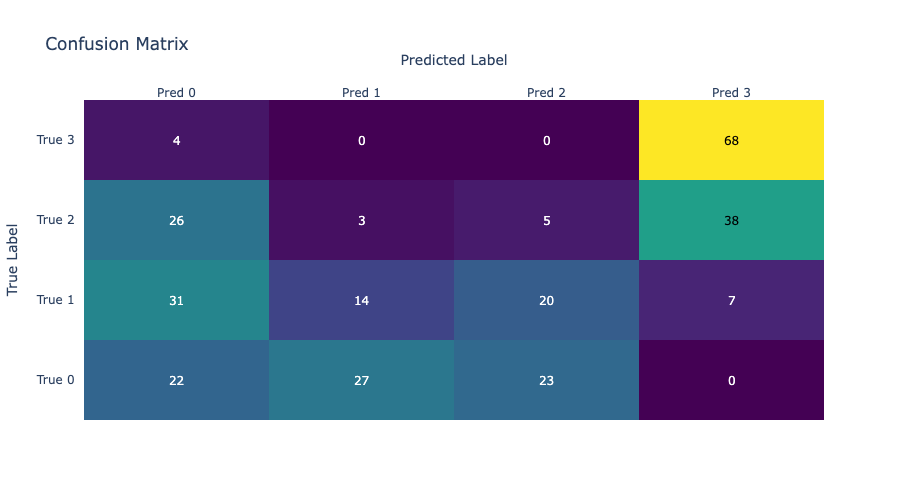

In [121]:
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(qs, [((l+2)%4)+1 for l in labels])
print(qs)
print([((l+2)%4) for l in labels])
# Normalize the confusion matrix by the true labels
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create the annotated heatmap
fig = ff.create_annotated_heatmap(
    z=cm_normalized,
    x=[f'Pred {i}' for i in range(cm.shape[1])],  # Column labels
    y=[f'True {i}' for i in range(cm.shape[0])],  # Row labels
    annotation_text=cm.astype(str),  # Annotate with actual values
    colorscale='Viridis'
)

# Update layout for better readability
fig.update_layout(
    title='Confusion Matrix',
    xaxis_title='Predicted Label',
    yaxis_title='True Label',
    height=500,
    width=600
)

fig.show()

In [8]:
from scipy.stats import pearsonr
import plotly.express as px

## Compute correlation coefficient between graph embedding PCA-1 and accuracy
# pearson correlation & linear regression (regression has predictive power)
# kendall / spearman -- non-linear but monotonic
# print(len(accs_by_q))
# print(len(X))

# Assuming X and labels are defined
# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(X)

# Extract the first principal component (PCA-1)
pca_1 = reduced_features[:, 0]

# Compute the Pearson correlation coefficient between PCA-1 and accuracies by quartile
correlation_coefficient, p_value = pearsonr(pca_1, accs_by_q)

print(f"Pearson correlation coefficient: {correlation_coefficient:.2f}")
print(f"P-value: {p_value:.4f}")

# Plotting PCA-1 vs. clustering scores
fig = px.scatter(
    x=pca_1,
    y=accs_by_q,
    color=qs,
    labels={'x': 'PCA Component 1', 'y': 'Quartile-level Path Accuracies', 'color': 'Quartile'},
    title=f'PCA-1 vs Quartile-level Path Accuracies  (Correlation: {correlation_coefficient:.2f})'
)

# Add a trendline to visualize the correlation
fig.update_traces(mode='markers')
fig.add_traces(
    go.Scatter(
        x=pca_1,
        y=np.poly1d(np.polyfit(pca_1, accs_by_q, 1))(pca_1),
        mode='lines',
        line=dict(color='red'),
        name='Trendline'
    )
)

# Adjust layout to prevent overlap
fig.update_layout(
    margin=dict(l=50, r=100, t=0, b=0),  # Adjust margins to provide space for the colorbar
    legend=dict(x=1.05, y=1, traceorder='normal', orientation='v'),  # Move legend to the right
    coloraxis_colorbar=dict(
        title='Quartile',  # Make sure colorbar title is clear
        tickvals=[min(qs), max(qs)],  # Example of setting specific tick values, adjust as needed
        ticktext=['1', '4'],  # Example of tick text
        len=0.5,  # Adjust the length of the colorbar
        yanchor='top'  # Align colorbar to the top
    )
)

fig.show()

Pearson correlation coefficient: -0.79
P-value: 0.0000


### Visualise clustering

Linear Regression Slope (Coefficient): -0.02
Intercept: 0.60
R-squared: 0.80


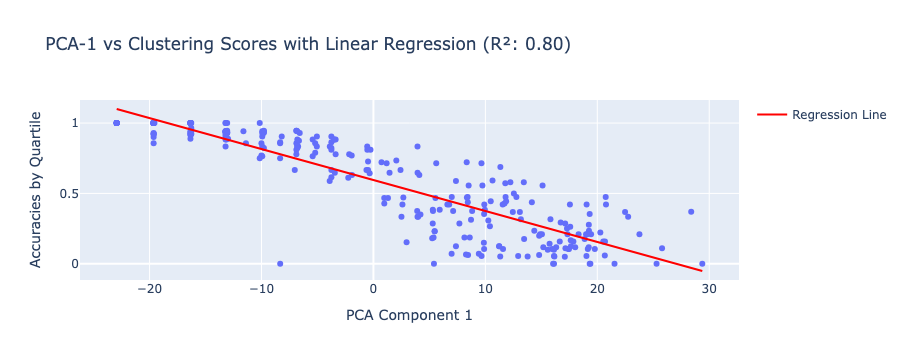

In [144]:
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Assuming X and labels are defined
# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Extract the first principal component (PCA-1)
pca_1 = reduced_features[:, 0]

# Reshape for sklearn (expects 2D array for features)
pca_1_reshaped = pca_1.reshape(-1, 1) #features#

# Initialize and fit the linear regression model
reg = LinearRegression()
reg.fit(pca_1_reshaped, accs_by_q)

# Predict clustering scores based on PCA-1
predicted_scores = reg.predict(pca_1_reshaped)

# Get the regression coefficient and intercept
slope = reg.coef_[0]
intercept = reg.intercept_

print(f"Linear Regression Slope (Coefficient): {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {reg.score(pca_1_reshaped, accs_by_q):.2f}")

# Plotting PCA-1 vs. clustering scores with regression line
fig = px.scatter(
    x=pca_1,
    y=accs_by_q,
    labels={'x': 'PCA Component 1', 'y': 'Accuracies by Quartile'},
    title=f'PCA-1 vs Clustering Scores with Linear Regression (R²: {reg.score(pca_1_reshaped, accs_by_q):.2f})'
)

df = pd.DataFrame({'X': pca_1, 'Y':predicted_scores})

# Add the regression line to the plot
fig.add_traces(
    go.Scatter(
        x=pca_1,
        y=predicted_scores,
        mode='lines',
        line=dict(color='red'),
        name='Regression Line'
    )
)

fig.show()

# look at what PCA 1 is -- correlate with known features -- branching, depth, etc
# loadings -- how input dimensions correspond with the output ones

## Explore

In [10]:
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
for index, row in test_df[["Subject", "quartile"]].iterrows():
    subj, q = row["Subject"], row["quartile"]
    if subj not in q_dict:
        q_dict[subj] = q

explore_df["quartile"] = explore_df["Subject"].map(q_dict)

In [11]:
from reeb_utils import collapse_traj

def compute_explore_traj(e_path):
    # need to replace V-east (V2) with Y and F-south (F3) with N
    # because they are facing and can see the object from there
    path = e_path.replace("V2", "Y2")
    path = e_path.replace("F3", "N3")
    
    nodes = path.split()
    nodes.remove("NA")
    nodes = [n[0] for n in nodes]

    return "".join(collapse_traj(nodes))

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

explore_df[["explore_traj", "quartile"]]

,explore_traj,quartile
0,URQTXVXZPZXTQHGLGAGHBCICDEMOMSRUTXTUWUTXVYVXZP...,3.0
50,RSMOMEDJKJRUWUTQRQTXVYVXZPZXTQHGLGAGHBCICDEMOM...,4.0
100,URQTXZPZXVXTURSMEFNFEDCICBHQHGAGLGHBCDJRJKJRUR...,2.0
110,UWURSMEFNFEDCBHGLGHGAGHQTXVYVXZPZXTUWURQHGAGLG...,3.0
160,DJRUWUTXVYVXZPZXTQRSMEFNFEDJRQHGLGAGHQTXVXZXTU...,1.0
...,...,...
4837,RJDCBHQTXVYVXTURJDEFNFEDCBHQTXVXZPZXTUWURSMEDC...,1.0
4887,URJDCBHGAGLGHQTXZPZXVXTUWURSMEFNFEDCBHGAGHQRJK...,2.0
4937,DJKJRQHBHGAGHQTXVYVXTQRSMOMSRJDEFNFEMSRUWUTXVX...,2.0
4987,RJDCICDEMOMSRJKJDCBHGLGHQRUWUTXVYVXZPZXTQHGAGL...,3.0


In [19]:
# not sure if it makes sense to do for objects... too sparse
# maybe for the central / hallway nodes?
objects = "ALPIKNOWY" 
hallways = "BCDEFGHJMQRSTUVXZ"
for a in hallways:
    min_len = 999
    for et in explore_df["explore_traj"]:
        trajs = []
        for i, s in enumerate(et): 
            if a in s:
                trajs.append(et[i: i+7])
        min_len = min(min_len, len(trajs))
    
    # print(a, min_len)

In [31]:
def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Number of Edges
    num_edges = graph.number_of_edges()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Average Node Degree
    avg_degree = np.mean([degree for node, degree in graph.degree()])
    
    # Diameter
    diameter = nx.diameter(graph)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Average Path Length
    avg_path_length = nx.average_shortest_path_length(graph)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Clustering Coefficient
    clustering_coeffs = nx.clustering(graph)
    avg_clustering_coeff = np.mean(list(clustering_coeffs.values()))
    
    # Put all features in a list
    features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        avg_clustering_coeff
    ]
    
    return features

In [146]:
from reeb_utils import all_traj_same

def simplify_path(path):
    nodes_visited = path.split()[:-1]
    
    simplified = ""
    for i in range(len(nodes_visited)-1):
        rt = {1:2, 2:3, 3:4, 4:1}
        lt = {2:1, 1:4, 4:3, 3:2}

        curr_node, next_node = nodes_visited[i], nodes_visited[i+1]
        if curr_node[0] != next_node[0]:
            # forward press
            simplified += "F"
        elif rt[int(curr_node[1])] == int(next_node[1]):
            # right turn
            simplified += "R"
        elif lt[int(curr_node[1])] == int(next_node[1]):
            # left turn
            simplified += "L"
        else:
            # print(curr_node, next_node)
            simplified += "R"
            ## N3 N1 spin
            # print("FUCK ME")
        
    return simplified

def generate_reeb_tree(start_i, start_node, trajs, which_trajs, G, visited, SUCCESS="", DEBUG=False):
    """Generates Reeb tree.

    TODO talk about what this means

    Parameters
    ----------
    start_i : TODO,
        TODO
    start_node : TODO,
        TODO
    trajs : list,
        Shape = [n_trajs, various]
        List of all trajectories over which to compute the Reeb tree.
    G : nx.Graph,
        Reeb tree to mutate in place as graph is construted.
    visited : TODO,
        TODO
    DEBUG : boolean,
        If True print more things.

    Returns
    -------
    None
    """
    if DEBUG: print(f"DO REEB, {start_i}, {start_node}, {which_trajs}")
    times_before = visited.get(start_node, 0) 
    visited[start_node] = times_before
    to_add = start_node + "_" + str(times_before)

    max_traj_len = max([len(trajs[t]) for t in which_trajs])

    ## BASE CASE 1: SINGLETON ##
    ## BASE CASE 2: ALL THE SAME ##
    if len(which_trajs) == 1 or all_traj_same(trajs, which_trajs, max_traj_len):
        end_node = trajs[which_trajs[0]][-1]
        times_before = visited.get(end_node, -1) + 1
        visited[end_node] = times_before
        
        end_node +=  "_" + str(times_before)
        if DEBUG: print(f"BASE CASE: {which_trajs}, last: {end_node}")

        color = "green" if SUCCESS in end_node else "yellow"
        G.add_node(end_node, color=color, end=True)
        G.add_edge(to_add, end_node, weight=len(which_trajs))

        return
    

    ## RECURSIVE STEP ##
    if DEBUG: print(f"FOR LOOP, {start_i}, {which_trajs}")
    for step in range(start_i, max_traj_len):
        
        new_gn = {}
        for i in which_trajs:
            traj = trajs[i]

            ## STOPPING CONDITION FOR THIS ONE GUY ##
            if step >= len(traj): 
                new_gn["DONE"] = new_gn.get("DONE", []).copy() + [i]
            else:
                new_node = traj[step]     
                new_gn[new_node] = new_gn.get(new_node, []).copy() + [i]

        if DEBUG: print("NEW_GN", new_gn)
        # decide whether we need a reeb node
        
        # people went different ways!!
        if len(new_gn.keys()) > 1:
            times_before = visited.get(start_node, 0)
            sn = start_node + "_" + str(times_before)
            
            

            if DEBUG: print("VISITED", visited)
            
            for k, v in new_gn.items():
                if DEBUG: print("RECURSE")

                # the thing happened at the node before this! all the paths in this fn are at the same point there so it doesnt mattter
                old_one = k#trajs[which_trajs[0]][step-1]
                times_before = visited.get(old_one, -1) + 1
                visited[old_one] = times_before

                

                on = k + "_" + str(times_before)
                G.add_node(on, color="blue", end=False)
                if DEBUG: print(f"ADDING NEW BLUE NODE {on}")
                
                G.add_edge(sn, on, weight=len(which_trajs))
                if DEBUG: print(f"ADDING NEW EDGE from {sn} to {on}, weight is {len(which_trajs)}")

                if DEBUG and k == "DONE":
                    print("*@#)$*$#()*(#@($")
                    print(new_gn)
                    
                generate_reeb_tree(step+1, old_one, trajs,  v, G, visited, SUCCESS=SUCCESS, DEBUG=DEBUG)

            return

etreebs = []
qs = []
for i, row in explore_df.iterrows():
    path = row["e_paths"]
    simplified_path = simplify_path(path)
    
    trajs = []
    salient_node = "F"
    for i in range(len(simplified_path)):
        if simplified_path[i] == salient_node:# if i%5 == 0:
            trajs.append(simplified_path[i: i+5])
    
    trajs = trajs[:25]
    # print(trajs)
    # print(len(trajs))
    G = nx.Graph()
    G.add_node(salient_node + "_0", color="red", end=False)
    
    if len(trajs) != 0:
        visited = {}
        generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
    
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

    etreebs.append(new_G.copy())

    if row["quartile"]:
            
        qs.append(row["quartile"])
    else:
        qs.append(1)
    # print(G.edges)
    # plot_treeb(G)

ARI: -0.01 (random would be: 0.01)
NMI: 0.02 (random would be: 0.03)
[0.99283461 0.00561029]


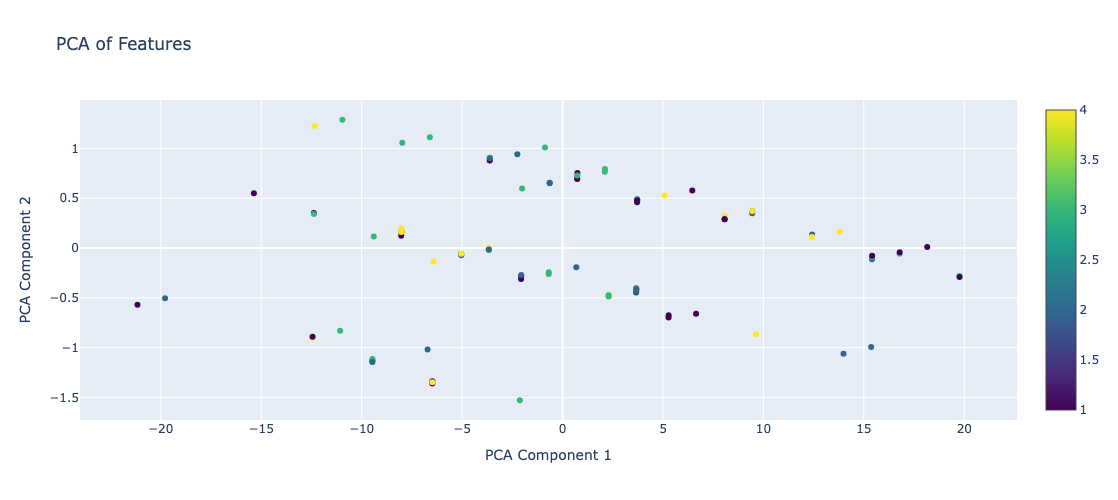

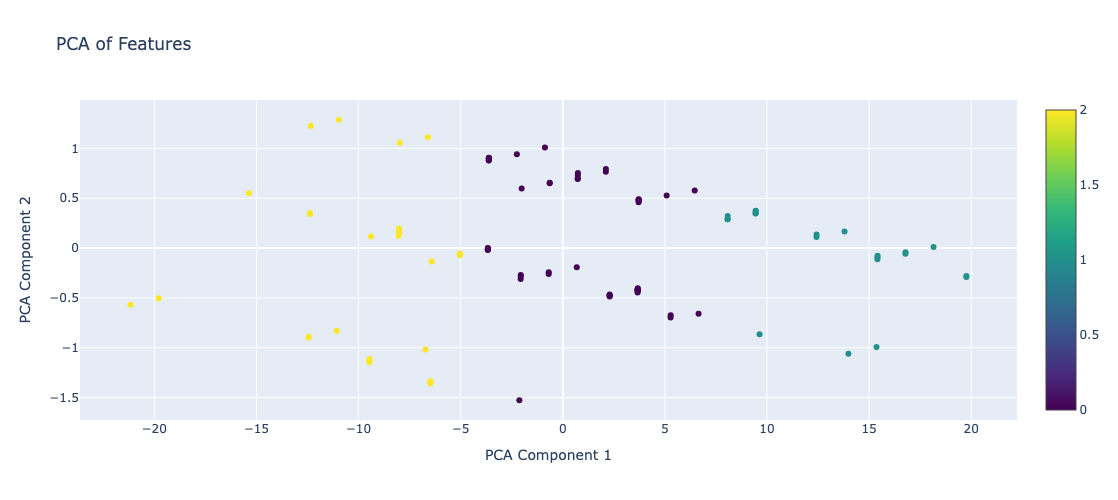

In [147]:
# e_treeb_dict = {}
# for salient_node in objects:
#     e_treebs, qs = compute_e_treebs_for_node(explore_df, salient_node)
#     e_treeb_dict[(salient_node, 0)] = e_treebs
# for salient_node in hallways:
#     e_treebs, qs = compute_e_treebs_for_node(explore_df, salient_node)
#     e_treeb_dict[(salient_node, 1)] = e_treebs
    
features = []
people = []
for i, graph in enumerate(etreebs):
    features.append(extract_tree_features(graph, 0))
    people.append(i)
features = np.array(features)

# explore_model = kc.Graph2Vec(dimensions=32)
# # model = kc.IGE()
# explore_model.fit(etreebs)

# e_X = explore_model.get_embedding()

# Specify the number of clusters
num_clusters = 3

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(features)

# Get the cluster assignments
labels = kmeans.labels_

## CALCULATE ACCURACY OF CLUSTERING!!!
true_labels = []
for l in qs:
    if not pd.isna(l):
        true_labels.append(l)
    else:
        true_labels.append(0)
baseline = [random.randint(0, 4) for _ in range(len(true_labels))]

print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")

# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)

# Plot the clusters with Plotly to have interactive
fig = go.Figure()

# Scatter plot for 'Trees by Quartile'
fig.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    text=people,
    marker=dict(color=qs, colorscale='Viridis', showscale=True),
    name='Trees by Quartile'
))

# Update layout
fig.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig.show()

# Plot the clusters with Plotly to have interactive
fig2 = go.Figure()

# Scatter plot for 'K-means Clustering of Graphs'
fig2.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=labels, colorscale='Viridis', showscale=True),
    name='K-means Clustering of Graphs'
))

# Update layout
fig2.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig2.show()

# predicting from features of tree; from embeddings; then from tree itself?

[[6.84448236e-01 6.84448236e-01 1.80333075e-02 7.71634815e-04
  4.39758818e-02 2.44472394e-01 3.21590545e-02 7.71634815e-04
  0.00000000e+00]
 [1.54335415e-02 1.54335415e-02 3.30153747e-01 3.75119142e-04
  8.77221535e-01 2.93193960e-01 1.87193787e-01 3.75119142e-04
  0.00000000e+00]]
1.9444444444444444
1.9444444444444444
1.9642857142857142


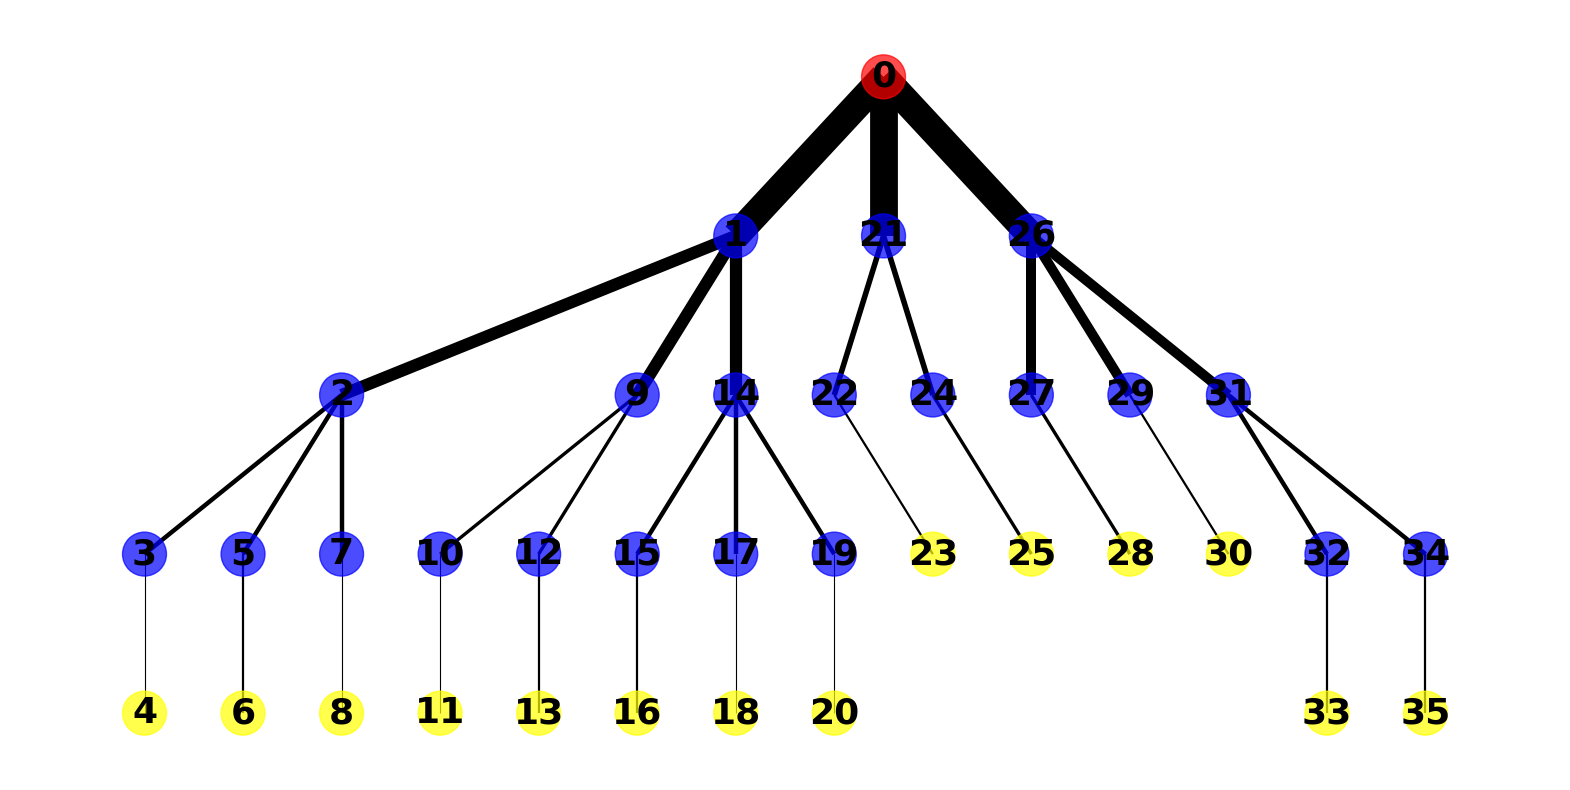

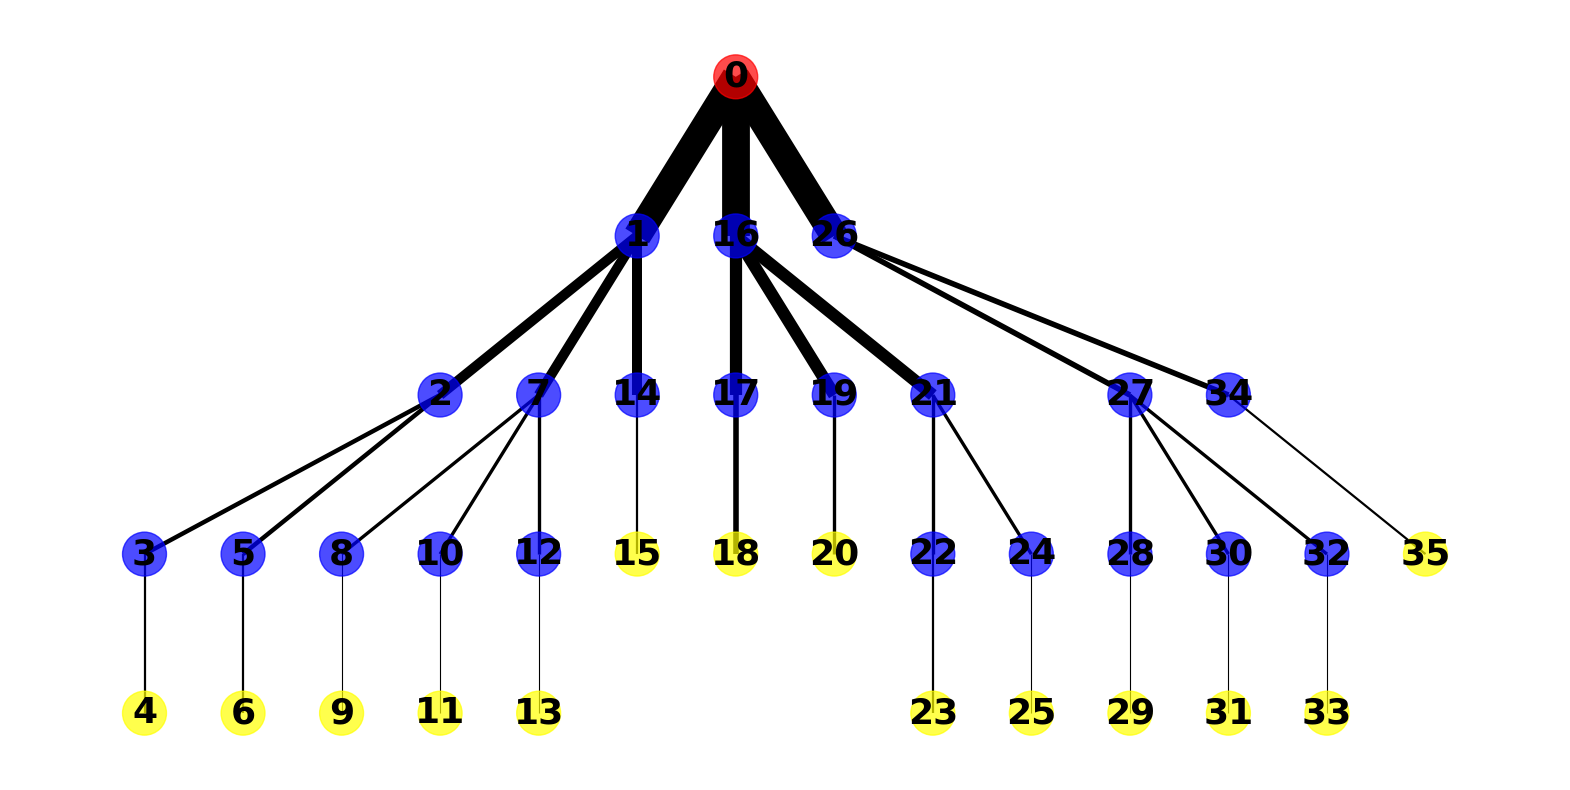

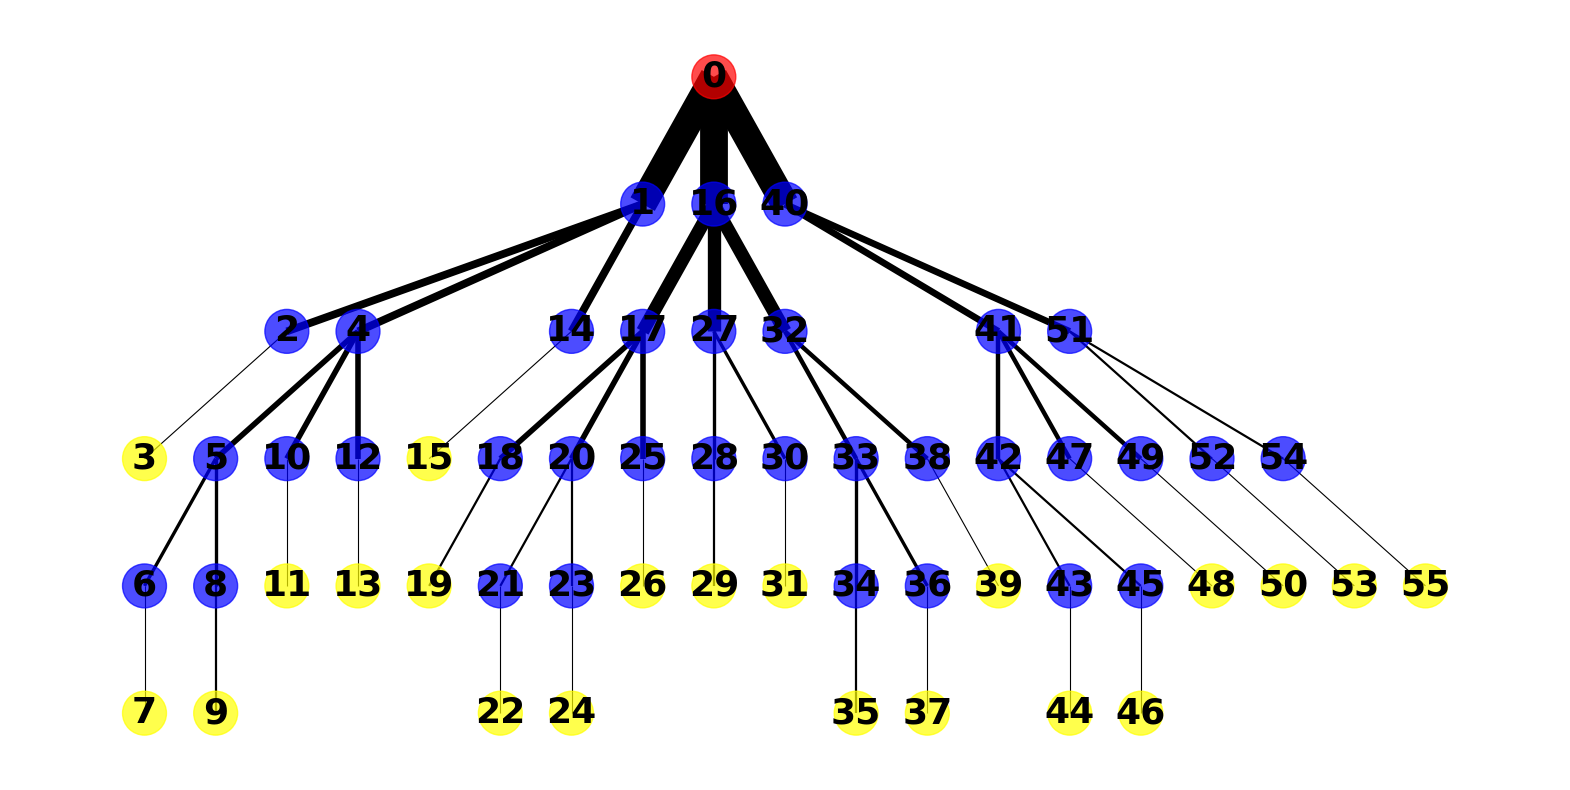

In [108]:
print(abs( pca.components_ ))

for i in [102, 87, 25]: ## 53 far from 84 75 close PCA1
    g = etreebs[i]
    plot_treeb(g)
    
    branching_factors = [len(list(g.neighbors(node))) for node in g.nodes()]
    print(np.mean(branching_factors))


OBJECTS
['AGHBCICDEMOMSRU', 'AGHBCICDEFNFEDJ', 'AGHQTUWUTXVXZPZ', 'AGHBCICDEFNFEMO']
['AGHBCICDEMOMSRJ', 'AGHBCDEFNFEMOMS', 'AGHDJRUTXVXZPZX', 'AGHBCICDJKJDEMO', 'AGLGHQTXZPZXVYV']
['AGLGHBCDJRJKJRU', 'AHGLGAGHQRSMOME', 'AGHQRSMOMEDJKJR', 'AGHBCDEFNFEMSMO', 'AGHQTUWURQHGLGH']
['AGHQTXVYVXZPZXT', 'AGLGHBCICDEMOMS', 'AGHBCICDJKJRSMO', 'AGHQTXZPZXVXTUW', 'AGHBCDEN']
['AGHQTXVXZXTURJK', 'AGLGHQTXZPZXVXT', 'AGLGHQTXZPZXVXT', 'AGHQRJDCICDEMOM']
['AGLGHBHQTXVYVXZ', 'AGHBCDJKEFNFEMO', 'AGLGHBHQTXZPZXV', 'AGLGHQTUWUTXVYV']
['AGLGHQTXZXVYVXT', 'AGHBCDEFNFEDJRU', 'AGHBCICDJRQTXZP', 'AGHBCDEMSMEDJKJ']
['AGHBCDJRSMEFNFE', 'AGHQTXZPZXTQHGA', 'AGHQRUWUTXVXZPZ', 'AGLGHQTXZPZXVYV', 'AGHQRJDCICICBHG']
['AGLGHQTXVYVXTUW', 'AGHBCDCICDEFNFE', 'AGHQTXVYVXZPBHG', 'AGLGAGHBCICBHQR', 'AGHBCICBHQRJKJR', 'AGLGHQTUWURJKJR', 'AGLGHQTXVYVXZPZ']
['AGLGHQRJKJRUWUT']
['AGHBCICDJKJDEFN', 'AGDEFNFEMOMSRUR', 'AGLGHQRUTXVXZPZ']
['AGLGHQTXVYVXTQR', 'AGLGHQRJKJRQTXV', 'AGLGHQRSMOMSRUW', 'AGHBCDJRQTUWURS']
['AGHQTURJKJRJDCB'

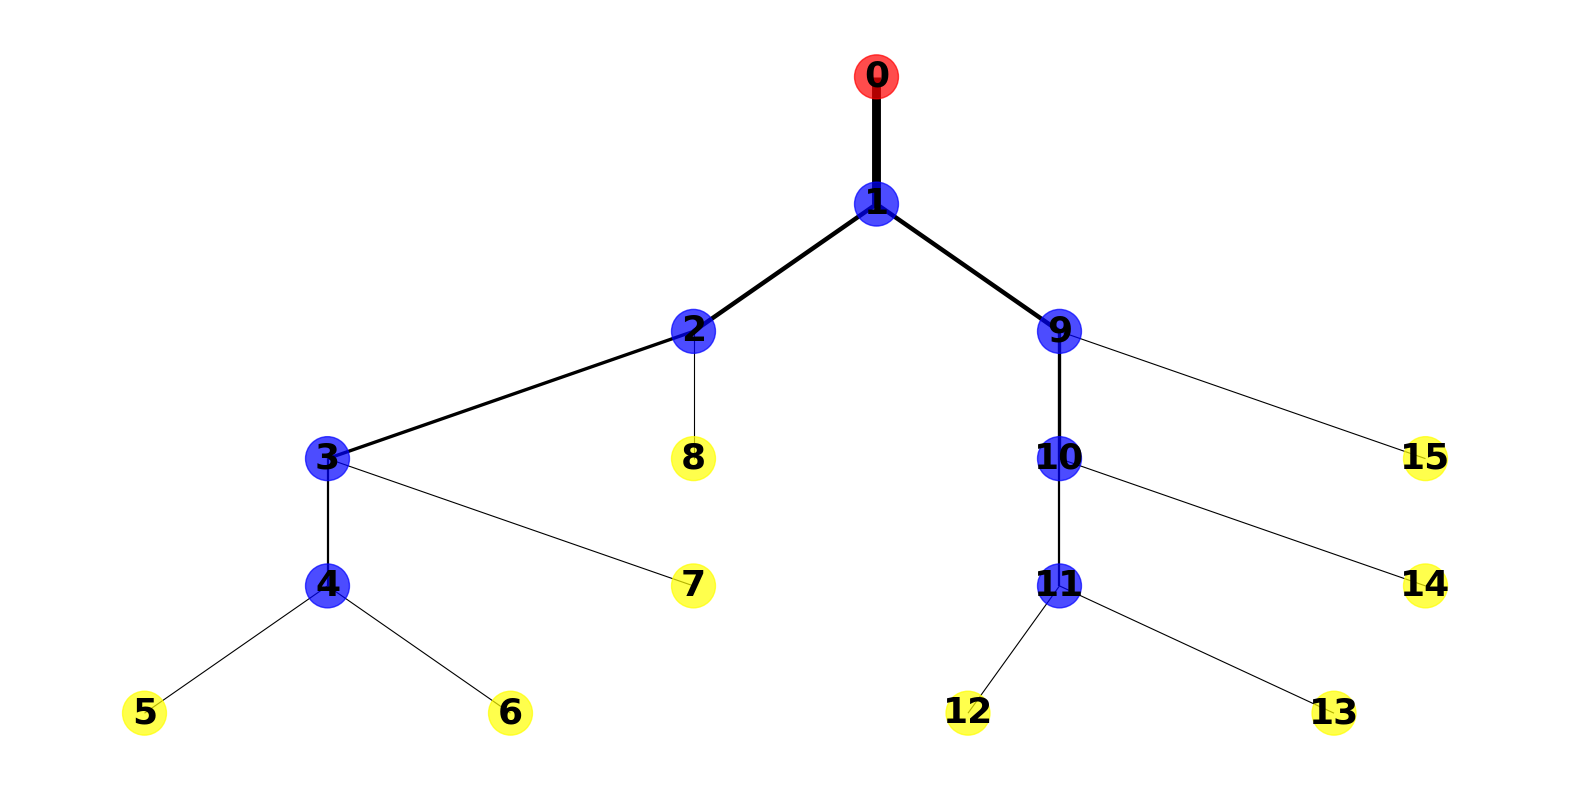

In [66]:
from reeb_utils import generate_reeb_tree
# Compute treebs 



def compute_simple_e_treebs(explore_df):
    e_treebs = []
    qs = []
    rounds = []
    for i, row in explore_df.iterrows():
        et = row["e_paths"]
        
        trajs = []
        for i, s in enumerate(et): 
            if salient_node in s:
                trajs.append(et[i: i+15])
    
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
    
        # print(trajs)
        # print(len(trajs))
        truncated_trajs = trajs.copy()

        if len(truncated_trajs) != 0:
            visited = {}
            generate_reeb_tree(0, salient_node, truncated_trajs, [i for i in range(len(truncated_trajs))], G, visited, SUCCESS="IMPOSSIBLE")
    
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    
        e_treebs.append(new_G.copy())
        if row["quartile"]:
            
            qs.append(row["quartile"])
        else:
            qs.append(1)
    return e_treebs, qs

def compute_e_treebs_for_node(explore_df, salient_node="A"):
    e_treebs = []
    qs = []
    # accs_by_q = []
    for i, row in explore_df.iterrows():
        et = row["explore_traj"]
        
        trajs = []
        for i, s in enumerate(et): 
            if salient_node in s:
                trajs.append(et[i: i+15])
    
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
    
        # print(trajs)
        # print(len(trajs))
        truncated_trajs = trajs.copy()
        print(truncated_trajs)

        if len(truncated_trajs) != 0:
            visited = {}
            generate_reeb_tree(0, salient_node, truncated_trajs, [i for i in range(len(truncated_trajs))], G, visited, SUCCESS="IMPOSSIBLE")
    
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    
        e_treebs.append(new_G.copy())
        if row["quartile"]:
            
            qs.append(row["quartile"])
        else:
            qs.append(1)
    return e_treebs, qs

def do_e_treeb_analysis(explore_df, salient_node="A", use_embeddings=True):
    e_treebs, qs = compute_e_treebs_for_node(explore_df, salient_node)


    ## See if they are predictively useful!
    
    explore_model = kc.Graph2Vec(dimensions=4)
    # model = kc.IGE()
    explore_model.fit(e_treebs)
    
    e_X = explore_model.get_embedding()
    # print(e_X.shape)
    # print(len(qs))

    # extract features for each graph
    features = np.array([extract_tree_features(g, 0) for g in e_treebs])
    # print(features[0])

    num_clusters = 4

    kmeans = KMeans(n_clusters=num_clusters, random_state=0)
    if use_embeddings:
        kmeans.fit(e_X)
    else:
        kmeans.fit(features)
    
    ll = kmeans.labels_
    labels = []
    for l in ll:
        if l:
            labels.append(l)
        else:
            labels.append(0)

    tt = [q-1 for q in qs]
    true_labels = []
    for l in tt:
        if not pd.isna(l):
            true_labels.append(l)
        else:
            true_labels.append(0)
            
    baseline = [random.randint(0, 4) for _ in range(len(true_labels))]
    
    # print(labels, true_labels)
    print(f"treeb of {salient_node}")
    print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
    print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")



    # Reduce dimensionality to 2D for visualization
    pca = PCA(n_components=2)
    reduced_features = pca.fit_transform(e_X)

    # to know if we can trust our eyes
    # if it is very low then the higher dimension info matters a lot & we can't see
    # above 0.7 is good!
    print("explained variance PCA", pca.explained_variance_ratio_)

e_treeb_dict = {}
print("OBJECTS")
all_qs = []
for salient_node in objects:
    e_treebs, qs = compute_e_treebs_for_node(explore_df, salient_node)
    all_qs.extend(qs)
    
    do_e_treeb_analysis(explore_df, salient_node, use_embeddings=False)
print("HALLWAYS")
for salient_node in hallways:
    e_treebs, qs = compute_e_treebs_for_node(explore_df, salient_node)
    all_qs.extend(qs)
    do_e_treeb_analysis(explore_df, salient_node, use_embeddings=False)


plot_treeb(e_treebs[0])


# predicting from features of tree; from embeddings; then from tree itself?
    
    # print(e_treebs)
    # print(qs)
    
    # for i in range(1,5):
    #     G = do_reeb_for_start_end(test_df, start_node, end_node, i, use_turns=False)
    #     new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    #     treebs.append(new_G)
    #     qs.append(i)
    #     accs_by_q.append(group[group["quartile"]==i]["path_mean_acc_by_Q"].iloc[0])

In [93]:
e_treeb_dict = {}
for salient_node in objects:
    e_treebs, qs = compute_e_treebs_for_node(explore_df, salient_node)
    e_treeb_dict[(salient_node, 0)] = e_treebs
for salient_node in hallways:
    e_treebs, qs = compute_e_treebs_for_node(explore_df, salient_node)
    e_treeb_dict[(salient_node, 1)] = e_treebs
    
features = []
node_type = []
nodes = []
people = []
for node in e_treeb_dict:
    i=0
    for graph in e_treeb_dict[node]:
        features.append(extract_tree_features(graph, 0))
        node_type.append(node[1])
        nodes.append(node[0])
        people.append(i)
        i+=1
features = np.array(features)

# Specify the number of clusters
num_clusters = 2

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(features)

# Get the cluster assignments
labels = kmeans.labels_

## CALCULATE ACCURACY OF CLUSTERING!!!
true_labels = node_type
baseline = [random.randint(0, 4) for _ in range(len(true_labels))]

print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")

# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)

# Plot the clusters with Plotly to have interactive
fig = go.Figure()

# Scatter plot for 'Trees by Quartile'
fig.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    text=node_type,
    marker=dict(color=node_type, colorscale='Viridis', showscale=True),
    name='Trees by Quartile'
))

# Update layout
fig.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig.show()

# Plot the clusters with Plotly to have interactive
fig2 = go.Figure()

# Scatter plot for 'K-means Clustering of Graphs'
fig2.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=labels, colorscale='Viridis', showscale=True),
    name='K-means Clustering of Graphs'
))

# Update layout
fig2.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig2.show()

# predicting from features of tree; from embeddings; then from tree itself?

['AGHBCICDEMOMSRU', 'AGHBCICDEFNFEDJ', 'AGHQTUWUTXVXZPZ', 'AGHBCICDEFNFEMO']
['AGHBCICDEMOMSRJ', 'AGHBCDEFNFEMOMS', 'AGHDJRUTXVXZPZX', 'AGHBCICDJKJDEMO', 'AGLGHQTXZPZXVYV']
['AGLGHBCDJRJKJRU', 'AHGLGAGHQRSMOME', 'AGHQRSMOMEDJKJR', 'AGHBCDEFNFEMSMO', 'AGHQTUWURQHGLGH']
['AGHQTXVYVXZPZXT', 'AGLGHBCICDEMOMS', 'AGHBCICDJKJRSMO', 'AGHQTXZPZXVXTUW', 'AGHBCDEN']
['AGHQTXVXZXTURJK', 'AGLGHQTXZPZXVXT', 'AGLGHQTXZPZXVXT', 'AGHQRJDCICDEMOM']
['AGLGHBHQTXVYVXZ', 'AGHBCDJKEFNFEMO', 'AGLGHBHQTXZPZXV', 'AGLGHQTUWUTXVYV']
['AGLGHQTXZXVYVXT', 'AGHBCDEFNFEDJRU', 'AGHBCICDJRQTXZP', 'AGHBCDEMSMEDJKJ']
['AGHBCDJRSMEFNFE', 'AGHQTXZPZXTQHGA', 'AGHQRUWUTXVXZPZ', 'AGLGHQTXZPZXVYV', 'AGHQRJDCICICBHG']
['AGLGHQTXVYVXTUW', 'AGHBCDCICDEFNFE', 'AGHQTXVYVXZPBHG', 'AGLGAGHBCICBHQR', 'AGHBCICBHQRJKJR', 'AGLGHQTUWURJKJR', 'AGLGHQTXVYVXZPZ']
['AGLGHQRJKJRUWUT']
['AGHBCICDJKJDEFN', 'AGDEFNFEMOMSRUR', 'AGLGHQRUTXVXZPZ']
['AGLGHQTXVYVXTQR', 'AGLGHQRJKJRQTXV', 'AGLGHQRSMOMSRUW', 'AGHBCDJRQTUWURS']
['AGHQTURJKJRJDCB', 'AGHQR

ValueError: Found input variables with inconsistent numbers of samples: [2756, 106]

In [14]:
print(treebs[0].nodes)
e_treebs[0].nodes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


NodeView((0, 1, 2, 3, 4, 5))

In [15]:
## Try to play a bit w the other ones to see if they work
# model = kc.WaveletCharacteristic()
# model = kc.FeatherGraph()
explore_model = kc.Graph2Vec(dimensions=6)
# model = kc.IGE()
explore_model.fit(e_treebs)

e_X = explore_model.get_embedding()
print(e_X.shape)

(106, 6)


37 {'[(0, 1), (1, 2), (1, 5), (2, 3), (2, 4)]': [3.0, 1.0, 3.0, 2.0, 2.0, 3.0, 1.0, 1.0, 4.0, 2.0, nan, 1.0, 2.0, 1.0, 1.0, 4.0, 2.0, 2.0, 1.0, 2.0, 3.0], '[(0, 1), (1, 2), (1, 9), (2, 3), (2, 8), (3, 4), (3, 7), (4, 5), (4, 6)]': [4.0], '[(0, 1), (1, 2), (1, 9), (2, 3), (2, 4), (4, 5), (4, 8), (5, 6), (5, 7)]': [2.0], '[(0, 1), (1, 2), (1, 9), (2, 3), (2, 6), (3, 4), (4, 5), (6, 7), (6, 8)]': [3.0], '[(0, 1), (1, 2), (1, 3), (3, 4), (3, 7), (4, 5), (4, 6)]': [1.0], '[(0, 1), (1, 2), (1, 9), (2, 3), (2, 4), (4, 5), (4, 6), (6, 7), (6, 8)]': [2.0], '[(0, 1), (1, 2), (2, 3), (2, 6), (2, 7), (3, 4), (3, 5), (7, 8), (7, 11), (8, 9), (8, 10)]': [2.0], '[(0, 1)]': [4.0, 1.0, 3.0, 1.0], '[(0, 1), (1, 2), (1, 3), (1, 4)]': [3.0, 2.0], '[(0, 1), (1, 2), (1, 7), (2, 3), (2, 4), (4, 5), (4, 6)]': [3.0, 3.0, 2.0, 3.0, 3.0, 1.0], '[(0, 1), (1, 2), (1, 6), (2, 3), (2, 4), (2, 5), (6, 7), (6, 8), (8, 9), (8, 10)]': [2.0], '[(0, 1), (1, 2), (1, 3), (3, 4), (3, 5)]': [4.0, 1.0, 2.0, 4.0, 3.0, 4.0, 1.0,

IndexError: index 2 is out of bounds for axis 0 with size 2

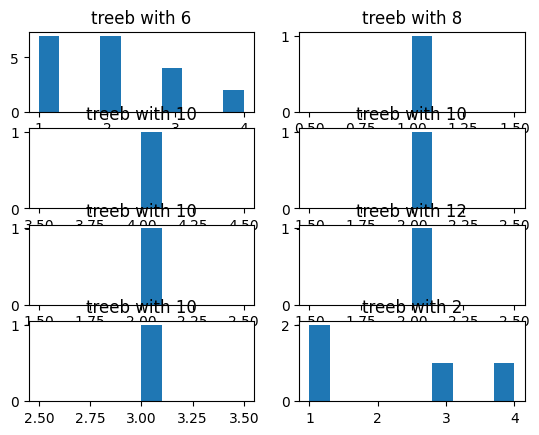

In [16]:
# ## Fake clusterer

# clusters = set()
# str_treebs = []
# dd = {}
# unique_trs = []
# for i, treeb in enumerate(e_treebs):
#     streeb = str(treeb.edges)
#     if streeb not in dd:
#         dd[streeb] = []
#         unique_trs.append(treeb)
#     dd[streeb].append(qs[i])

# # print(len(e_treebs))
# print(len(dd.keys()), dd)

# fig, axes = plt.subplots(4,2)
# count = 0
# for d in dd:
#     ax = axes[count % 4][count // 4]
#     ax.hist(dd[d])
#     count += 1
#     ax.set_title(f"treeb with {len(d.split('('))}")

# fig.suptitle("Explore Treeb R by quartile")
# plt.show()

In [ ]:
num_clusters = 4

kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(e_X)

ll = kmeans.labels_
labels = []
for l in ll:
    if l:
        labels.append(l)
    else:
        labels.append(0)

In [ ]:
tt = [q-1 for q in qs]
true_labels = []
for l in tt:
    if not pd.isna(l):
        true_labels.append(l)
    else:
        true_labels.append(0)
        
baseline = [random.randint(0, 4) for _ in range(len(true_labels))]

print(labels, true_labels)
print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")



# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(e_X)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)

# Plot the clusters with Plotly to have interactive
fig = go.Figure()

# Scatter plot for 'Trees by Quartile'
fig.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=qs, colorscale='Viridis', showscale=True),
    name='Trees by Quartile'
))

# Update layout
fig.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig.show()

# Plot the clusters with Plotly to have interactive
fig2 = go.Figure()

# Scatter plot for 'K-means Clustering of Graphs'
fig2.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=labels, colorscale='Viridis', showscale=True),
    name='K-means Clustering of Graphs'
))

# Update layout
fig2.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig2.show()

# predicting from features of tree; from embeddings; then from tree itself?

#### Tree plotting works now!

In [17]:
## Debugging if graphviz / dot is being annoying:

# import os
# print(os.environ['PATH'])

# import subprocess

# try:
#     subprocess.run(["dot", "-V"], check=True)
#     print("dot is accessible")
# except FileNotFoundError:
#     print("dot not found in PATH")

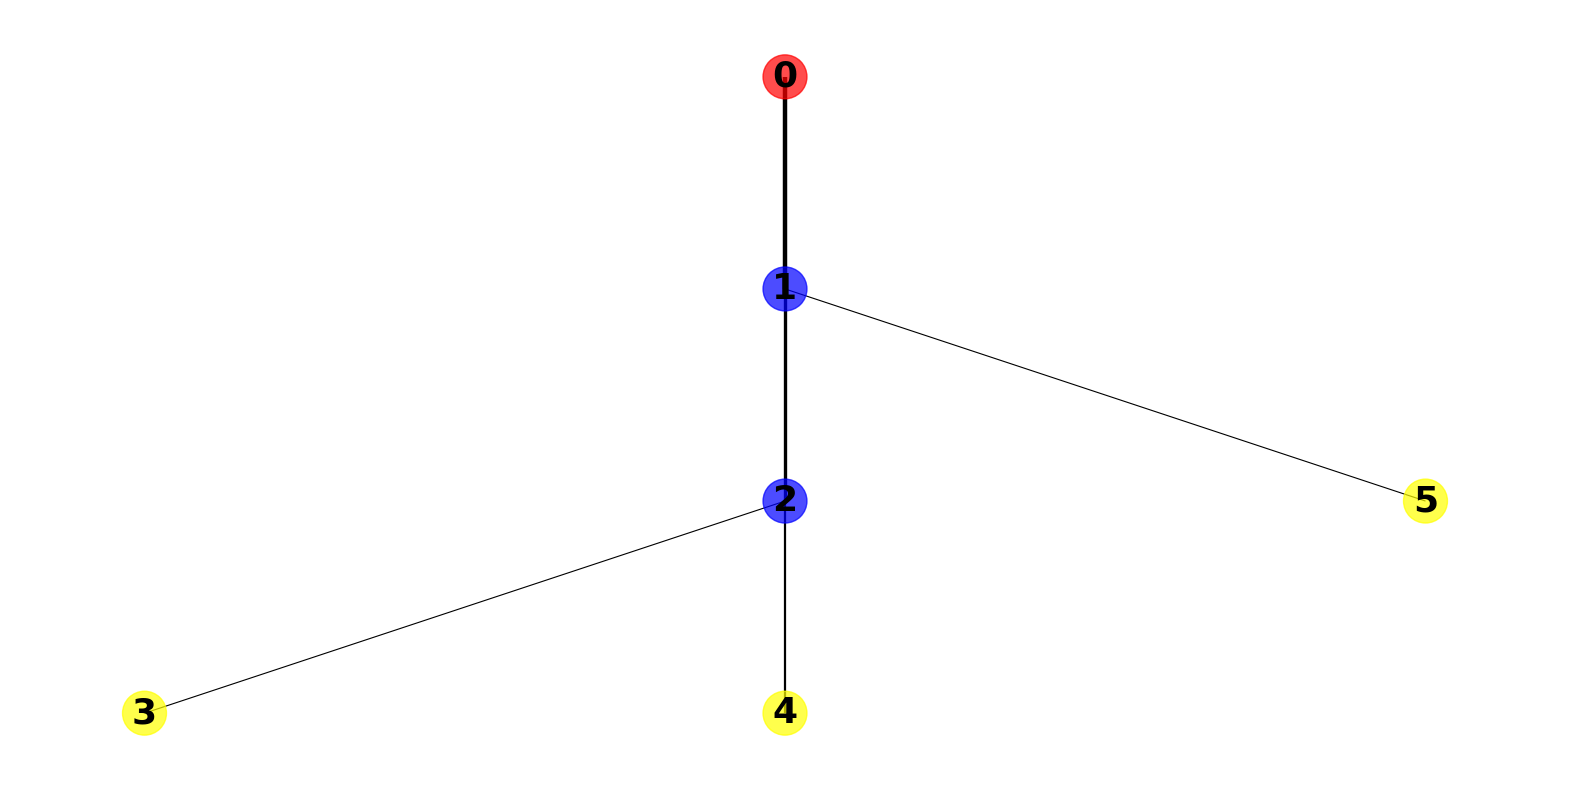

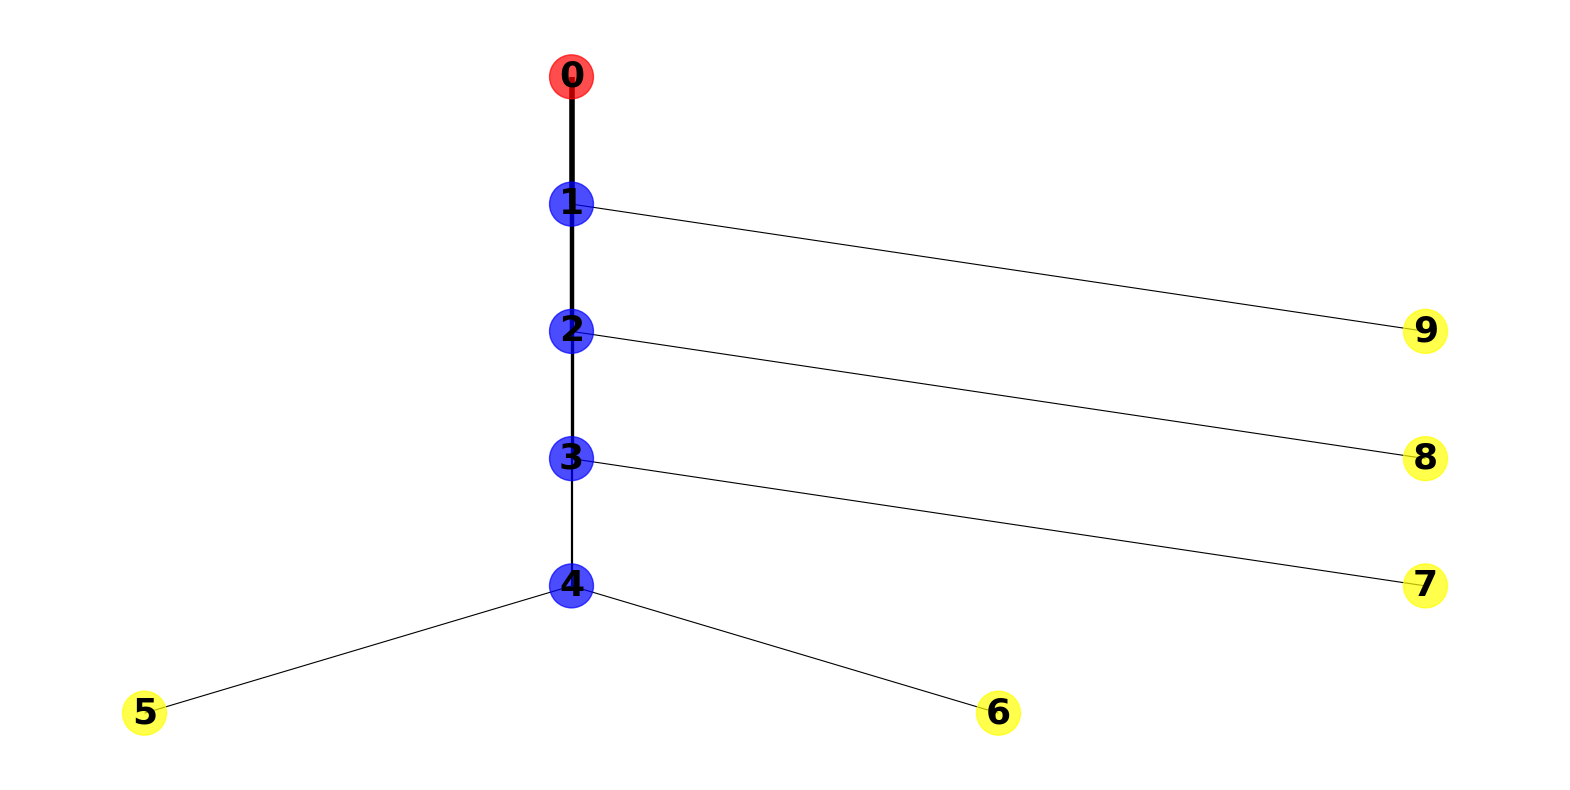

In [18]:
# NOTE GRAPHING DOES NOT WORK IN THIS ENV

def plot_treeb(G):
    fig = plt.figure(figsize=(20,10))
    this_ax = plt.gca()

    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    # colors = [G[u][v]['color'] for u,v in edges]
    weights = [G[u][v]['weight'] * .8 for u,v in edges]

    nodes = G.nodes()
    # for n in nodes:
    #     print(n, G.nodes[n])
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
    # print(n_colors)
    # print ((q-1) // 2, (q-1) % 2)
    nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=1000, alpha=0.7, ax=this_ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
    nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=26, font_weight="bold", ax=this_ax)

    this_ax.axis("off")
    
# G = do_reeb_for_start_end(test_df, "A", "W", 1, use_turns=True)
# print(e_treebs[2] == e_treebs[0])
# print(e_treebs[0].edges == e_treebs[2].edges)
# plot_treeb(e_treebs[0])
# print(e_treebs[2].edges)
# plot_treeb(e_treebs[2])

count = 10
for tr in unique_trs:
    plot_treeb(tr)
    if count > 10:
        break
    count += 1